# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Необходимо построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания
- скорость предсказания
- время обучения

**Описание данных**

- _DateCrawled_ — дата скачивания анкеты из базы
- _VehicleType_ — тип автомобильного кузова
- _RegistrationYear_ — год регистрации автомобиля
- _Gearbox_ — тип коробки передач
- _Power_ — мощность (л. с.)
- _Model_ — модель автомобиля
- _Kilometer_ — пробег (км)
- _RegistrationMonth_ — месяц регистрации автомобиля
- _FuelType_ — тип топлива
- _Brand_ — марка автомобиля
- _Repaired_ — была машина в ремонте или нет
- _DateCreated_ — дата создания анкеты
- _NumberOfPictures_ — количество фотографий автомобиля
- _PostalCode_ — почтовый индекс владельца анкеты (пользователя)
- _LastSeen_ — дата последней активности пользователя

**Целевой признак**

_Price_ — цена (евро)

In [56]:
# загрузка библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

from sklearn.metrics import mean_squared_error

from lightgbm import LGBMRegressor

try:
    import phik
except:
    !pip install phik -q
    import phik
    
import warnings
warnings.filterwarnings('ignore')

## Загрузка данных

In [57]:
data = pd.read_csv('/datasets/autos.csv')

In [58]:
data.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


Выведем общую информацию

In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

Предварительно видно, что признаки, хранящие даты записаны как строки, также есть пропуски в полях `VehicleType`, `FuelType`, `Repaired`

## Предобработка данных

### Обработка аномалий

Выведем статистические данные по всем признакам

In [60]:
for col in data.columns:
    print(col)
    print(data[col].describe())
    print()

DateCrawled
count                  354369
unique                 271174
top       2016-03-24 14:49:47
freq                        7
Name: DateCrawled, dtype: object

Price
count    354369.000000
mean       4416.656776
std        4514.158514
min           0.000000
25%        1050.000000
50%        2700.000000
75%        6400.000000
max       20000.000000
Name: Price, dtype: float64

VehicleType
count     316879
unique         8
top        sedan
freq       91457
Name: VehicleType, dtype: object

RegistrationYear
count    354369.000000
mean       2004.234448
std          90.227958
min        1000.000000
25%        1999.000000
50%        2003.000000
75%        2008.000000
max        9999.000000
Name: RegistrationYear, dtype: float64

Gearbox
count     334536
unique         2
top       manual
freq      268251
Name: Gearbox, dtype: object

Power
count    354369.000000
mean        110.094337
std         189.850405
min           0.000000
25%          69.000000
50%         105.000000
75%       

В столбце `Price` есть значения 0, удалим эти строки

In [61]:
data = data[data['Price'] > 0]

В столбце `RegistrationYear` есть аномально маленькие и аномально большие значения, удалим эти строки

In [62]:
data = data[(data['RegistrationYear'] > 1960) & (data['RegistrationYear'] <= 2016)]

В столбце `Power` есть аномально маленькие и аномально большие значения

Большие значения удалим, а нули заменим на среднее

In [63]:
data = data[data['Power'] < 400]
data['Power'] = data['Power'].replace(0, data['Power'].mean())

В столбце `RegistrationMonth` есть нули, заменим их на среднее значение

In [64]:
data['RegistrationMonth'] = data['RegistrationMonth'].replace(0, data['RegistrationMonth'].mean())

### Удаление ненужных столбцов

В столбце `NumberOfPictures` вообще нет данных, удалим его

In [65]:
data = data.drop('NumberOfPictures', axis=1)

Столбцы с датами активности пользователя и почтового индекса вряд ли влияют на цену машины, удалим их

In [66]:
data = data.drop(['DateCrawled', 'DateCreated', 'LastSeen', 'PostalCode'], axis=1)

### Обработка неявных дубликатов

Выведем уникальные значения категориальных признаков

In [67]:
for col in data.select_dtypes(exclude='number').columns:
    print(col)
    print(data[col].unique())
    print()

VehicleType
[nan 'coupe' 'suv' 'small' 'sedan' 'convertible' 'bus' 'wagon' 'other']

Gearbox
['manual' 'auto' nan]

Model
['golf' nan 'grand' 'fabia' '3er' '2_reihe' 'c_max' '3_reihe' 'passat'
 'navara' 'polo' 'twingo' 'a_klasse' 'scirocco' '5er' 'arosa' 'other'
 'civic' 'transporter' 'punto' 'e_klasse' 'clio' 'kadett' 'kangoo' 'one'
 'fortwo' '1er' 'b_klasse' 'signum' 'astra' 'a8' 'jetta' 'fiesta'
 'c_klasse' 'micra' 'vito' 'sprinter' '156' 'escort' 'forester' 'xc_reihe'
 'scenic' 'a4' 'ka' 'a1' 'insignia' 'combo' 'focus' 'tt' 'corsa' 'a6'
 'jazz' 'omega' 'slk' '7er' '80' '147' '100' 'z_reihe' 'sorento' 'v40'
 'ibiza' 'mustang' 'eos' 'touran' 'getz' 'a3' 'almera' 'megane' 'lupo'
 'r19' 'caddy' 'mondeo' 'cordoba' 'colt' 'impreza' 'vectra' 'berlingo'
 'tiguan' 'sharan' '6_reihe' 'c4' 'panda' 'up' 'i_reihe' 'ceed' '5_reihe'
 'yeti' 'octavia' 'zafira' 'mii' 'rx_reihe' '6er' 'modus' 'fox' 'matiz'
 'beetle' 'c1' 'rio' 'touareg' 'logan' 'spider' 'cuore' 's_max' 'a2'
 'galaxy' 'c3' 'viano' 's

`petrol` и `gasoline` - разные названия одного и того же топлива, оставим только вариант `petrol`

In [68]:
data.loc[data['FuelType'] == 'gasoline', 'FuelType'] = 'petrol'

### Обработка пропусков

In [69]:
print('Кол-во пропусков')
for col in data.columns:
    if(data[col].isna().sum() > 0):
        print(f'{col}: {data[col].isna().sum()}')

Кол-во пропусков
VehicleType: 19776
Gearbox: 15419
Model: 15398
FuelType: 23952
Repaired: 59499


В столбцах `VehicleType`, `Model`, `FuelType` заменим пропуски на 'other'

В остальных столбцах на 'unknown'

In [70]:
data['VehicleType'] = data['VehicleType'].fillna('other')
data['Model'] = data['Model'].fillna('other')
data['FuelType'] = data['FuelType'].fillna('other')

data['Gearbox'] = data['Gearbox'].fillna('unknown')
data['Repaired'] = data['Repaired'].fillna('unknown')

Проверим

In [71]:
print('Кол-во пропусков')
for col in data.columns:
    if(data[col].isna().sum() > 0):
        print(f'{col}: {data[col].isna().sum()}')
    else:
        print(f'{col}: 0')

Кол-во пропусков
Price: 0
VehicleType: 0
RegistrationYear: 0
Gearbox: 0
Power: 0
Model: 0
Kilometer: 0
RegistrationMonth: 0
FuelType: 0
Brand: 0
Repaired: 0


### Обработка дубликатов

In [72]:
data.duplicated().sum()

25675

Удалим дубликаты

In [73]:
data = data.drop_duplicates()

Проверим

In [74]:
data.duplicated().sum()

0

**Вывод**

- Были удалены столбцы `PostalCode`, `DateCrawled`, `DateCreated`, `LastSeen`, как невлияющие на стоимость автомобиля, `NumberOfPictures` - пустой, тоже удалён
- В столбце `Price` удалены нули
- В столбце `RegistrationYear` удалены аномально маленькие и аномально большие значения
- В столбце `Power` есть аномально маленькие и аномально большие значения
- В столбце `RegistrationMonth` нули заменены на среднее значение
- В столбцах `VehicleType`, `Model`, `FuelType` пропуски заменены на 'other', в остальных столбцах на 'unknown'
- Удалены дублирующиеся строки

## Исследовательский анализ данных

In [75]:
# функция вывода характеристик количественного признака
def feature_stat(feature, title, ylabel, bins=50):
    fig, axes = plt.subplots(ncols=1, nrows=2, gridspec_kw={'height_ratios' : [15, 85]}, figsize=(8, 5), sharex=True)
    axes[0].boxplot(feature, vert=False)
    axes[0].set_title(title)
    
    axes[1].hist(feature, bins=bins)
    axes[1].set_ylabel(ylabel)
    axes[1].axvline(feature.mean(), color='red', linestyle='-', linewidth=2, label=f'Среднее: {feature.mean():.2f}')
    axes[1].axvline(feature.median(), color='red', linestyle='--', linewidth=2, label=f'Медиана: {feature.median():.2f}')
    
    plt.tight_layout()
    plt.legend()
    plt.grid()
    plt.show()
    print(feature.describe().T)

In [76]:
def feature_stat_categ(feature, title_name, ylim=100):
    plt.figure(figsize=(10,6)) 
    
    percent_list = []
    for j in range(len(sorted(feature.unique()))):
        percent_list.append(((feature == sorted(feature.unique())[j]).sum() / feature.size)*100)
        
    bars = plt.bar(sorted(feature.unique()), percent_list,
              color=['blue','skyblue', 'red', 'lightcoral', 'green', 'lightgreen'], alpha=0.8, width=0.6)
    for i, v in enumerate(percent_list):
        plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom')
    plt.xticks(rotation=45)
    plt.title(title_name)
    plt.ylabel('%')
    plt.ylim(0, ylim)
    plt.show()

**Тип автомобильного кузова `VehicleType`**

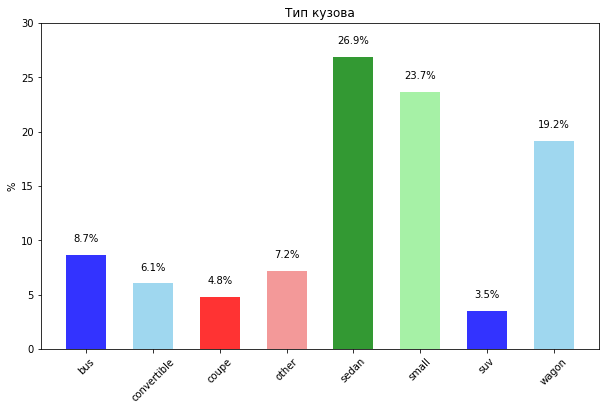

In [78]:
feature_stat_categ(data['VehicleType'], 'Тип кузова', ylim=30)

Больше всего кузовов типа `sedan` и `small`, меньше всего `suv`

**Год регистрации автомобиля `RegistrationDate`**

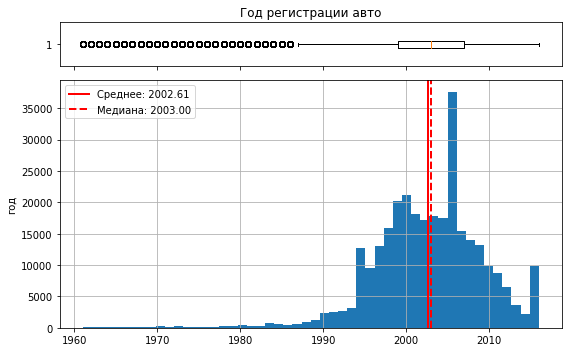

count    302964.000000
mean       2002.613050
std           6.682704
min        1961.000000
25%        1999.000000
50%        2003.000000
75%        2007.000000
max        2016.000000
Name: RegistrationYear, dtype: float64


In [79]:
feature_stat(data['RegistrationYear'], 'Год регистрации авто', 'год')

Данные распределены нормально, но есть выбросы в меньшую сторону, удалим их

In [80]:
data = data[data['RegistrationYear']>=1990]

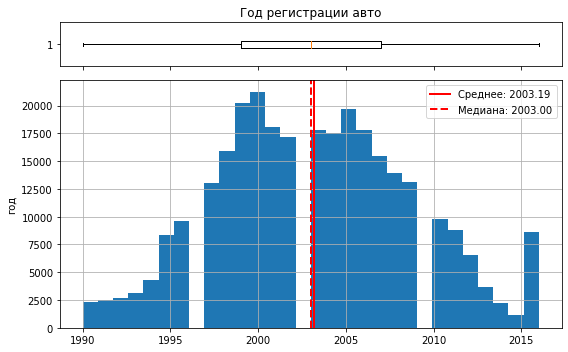

count    294879.000000
mean       2003.194754
std           5.637261
min        1990.000000
25%        1999.000000
50%        2003.000000
75%        2007.000000
max        2016.000000
Name: RegistrationYear, dtype: float64


In [81]:
feature_stat(data['RegistrationYear'], 'Год регистрации авто', 'год', bins = 30)

**Тип коробки передач `Gearbox`**

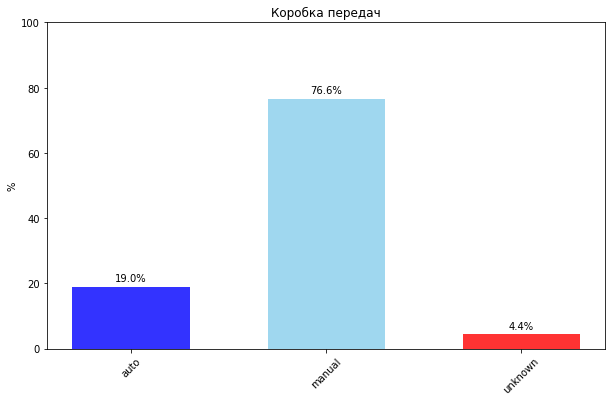

In [82]:
feature_stat_categ(data['Gearbox'], 'Коробка передач')

Больше всего автомобилей с механической коробкой передач

**Мощность (л.с) `Power`**

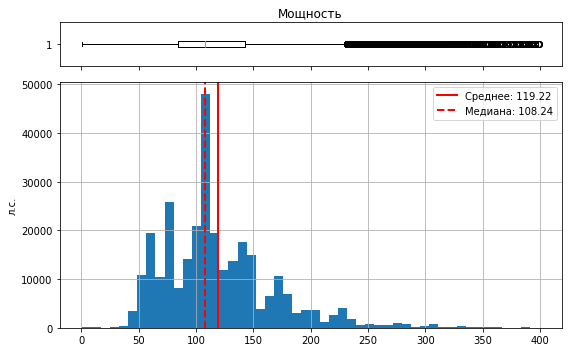

count    294879.000000
mean        119.220011
std          49.773467
min           1.000000
25%          84.000000
50%         108.244606
75%         143.000000
max         399.000000
Name: Power, dtype: float64


In [83]:
feature_stat(data['Power'], 'Мощность', 'л.с.')

Данные распределены нормально, но есть выбросы, удалим их

**Модель автомобиля `Model`**

Найдём 10 самых популярных моделей

In [86]:
percent_model_list = []
for j in range(len(sorted(data['Model'].unique()))):
    percent_model_list.append(round((((data['Model'] == sorted(data['Model'].unique())[j]).sum() / data['Model'].size)*100),1))
model_and_percent = dict(zip(sorted(data['Model'].unique()), percent_model_list))
sorted_model_and_percent = sorted(model_and_percent.items(), key=lambda x: x[1], reverse=True)

In [87]:
list(sorted_model_and_percent)[:10]

[('other', 11.0),
 ('golf', 8.0),
 ('3er', 5.7),
 ('polo', 3.7),
 ('corsa', 3.5),
 ('astra', 3.1),
 ('a4', 2.9),
 ('passat', 2.9),
 ('c_klasse', 2.4),
 ('5er', 2.3)]

Самая популярная модель - `golf`

**Пробег (км) `Kilometer`**

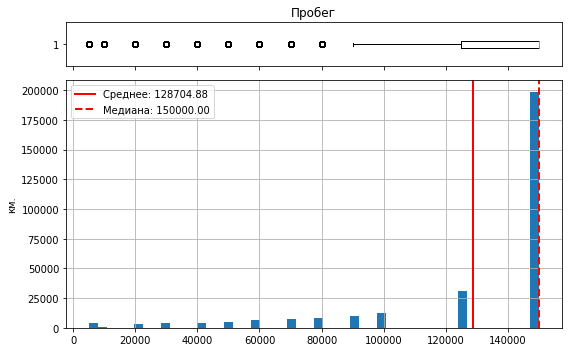

count    294879.000000
mean     128704.875559
std       37000.707042
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: Kilometer, dtype: float64


In [88]:
feature_stat(data['Kilometer'], 'Пробег', 'км.')

Данные распределены не нормально, больше всего автомобилей с пробегом ~150000

**Месяц регистрации автомобиля `RegistrationMonth`**

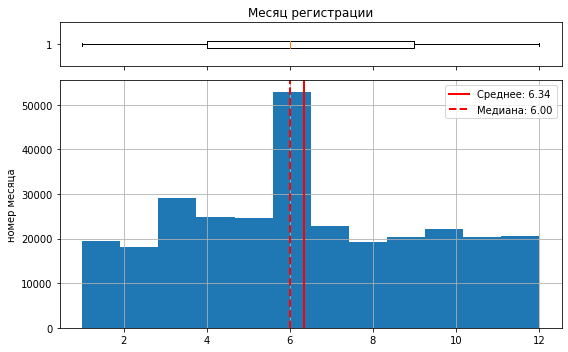

count    294879.000000
mean          6.337651
std           3.200741
min           1.000000
25%           4.000000
50%           6.000000
75%           9.000000
max          12.000000
Name: RegistrationMonth, dtype: float64


In [89]:
feature_stat(data['RegistrationMonth'], 'Месяц регистрации', 'номер месяца', 12)

Данные распределены равномерно

**Была ли машина в ремонте или нет `Repaired`**

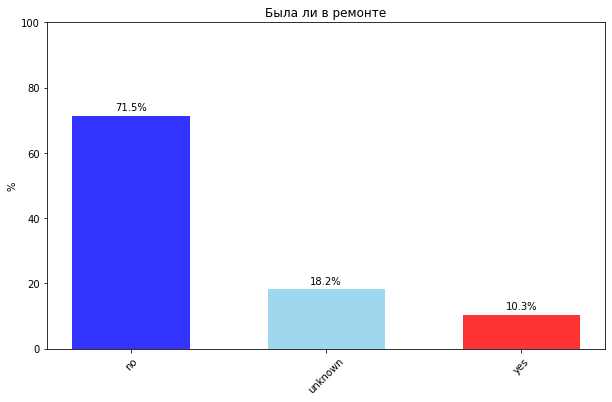

In [90]:
feature_stat_categ(data['Repaired'], 'Была ли в ремонте')

71% машин не было в ремонте

**Тип топлива `FuelType`**

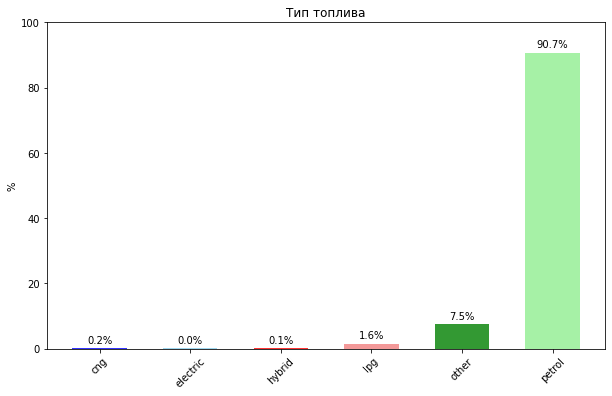

In [91]:
feature_stat_categ(data['FuelType'], 'Тип топлива')

Больше всего машин на бензиновом топливе

**Марка автомобиля `Brand`**

Найдём 10 самых популярных

In [92]:
percent_brand_list = []
for j in range(len(sorted(data['Brand'].unique()))):
    percent_brand_list.append(round((((data['Brand'] == sorted(data['Brand'].unique())[j]).sum() / data['Brand'].size)*100),1))
brand_and_percent = dict(zip(sorted(data['Brand'].unique()), percent_brand_list))
sorted_brand_and_percent = sorted(brand_and_percent.items(), key=lambda x: x[1], reverse=True)

In [93]:
list(sorted_brand_and_percent)[:10]

[('volkswagen', 21.1),
 ('opel', 11.2),
 ('bmw', 10.5),
 ('mercedes_benz', 9.0),
 ('audi', 8.3),
 ('ford', 7.2),
 ('renault', 5.1),
 ('peugeot', 3.3),
 ('fiat', 2.7),
 ('seat', 2.0)]

Самая популярная марка - `volkswagen`

**Вывод**

Удалены выбросы в столбцах `RegistrationYear` и `Power`

## Корреляционный анализ

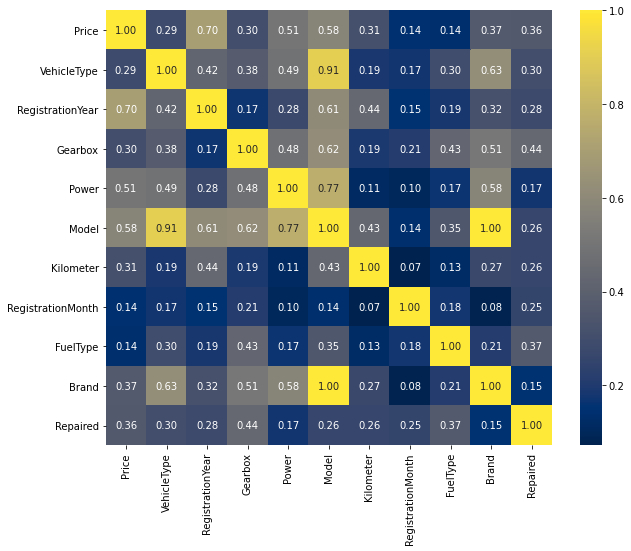

In [94]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.phik_matrix(interval_cols= data.select_dtypes(include='number').columns), annot=True, fmt='.2f', cmap='cividis')
plt.show()

Мультиколлинеарности не наблюдается, больше всего корреляция у целевого признака `Price` с признаками `RegistrationYear`, `Model` и `Power`

## Обучение моделей

In [95]:
RANDOM_STATE = 72

### Подготовка данных

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop('Price', axis=1),
    data['Price'],
    random_state=RANDOM_STATE
)

Разобьём выборку на обучающую и тестовую

In [97]:
ohe_cols = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired']
num_cols = ['RegistrationYear', 'Power', 'Kilometer', 'RegistrationMonth']

Количественные признаки отмасштабируем с помощью MinMaxScaler

In [98]:
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[num_cols]), columns = num_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[num_cols]), columns = num_cols)

Категориальные переменные закодируем с помощью OneHotEncoder

In [99]:
encoder = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = pd.DataFrame(encoder.fit_transform(X_train[ohe_cols]), columns = encoder.get_feature_names())
X_test_ohe = pd.DataFrame(encoder.transform(X_test[ohe_cols]), columns = encoder.get_feature_names())

Объединим количественные и категориальные признаки

In [100]:
X_train_res = pd.concat([X_train_scaled, X_train_ohe], axis=1)
X_test_res = pd.concat([X_test_scaled, X_test_ohe], axis=1)

Модель LightGBM не требует кодирования категориальных признаков, поэтому для неё создадим отдельный набор данных

In [101]:
X_train.index = X_train_scaled.index
X_test.index = X_test_scaled.index
X_train_lgbm = pd.concat([X_train_scaled, X_train[ohe_cols].sort_index()], axis=1)
X_test_lgbm = pd.concat([X_test_scaled, X_test[ohe_cols].sort_index()], axis=1)

Приведём категориальные признаки к типу `category`

In [102]:
X_train_lgbm[ohe_cols] = X_train_lgbm[ohe_cols].astype('category')
X_test_lgbm[ohe_cols] = X_test_lgbm[ohe_cols].astype('category')

In [103]:
del data
del X_train
del X_test
del X_train_scaled
del X_test_scaled
del X_train_ohe
del X_test_ohe

### Обучение линейной регрессии (LinearRegression)

In [52]:
params_lr = {
    'fit_intercept' : [True, False]
}

randomized_search_lr = RandomizedSearchCV(
    LinearRegression(),
    param_distributions = params_lr,
    n_jobs = -1,
    n_iter = 2,
    scoring = 'neg_root_mean_squared_error',
    random_state = RANDOM_STATE
)

randomized_search_lr.fit(X_train_res, y_train)

RandomizedSearchCV(estimator=LinearRegression(), n_iter=2, n_jobs=-1,
                   param_distributions={'fit_intercept': [True, False]},
                   random_state=72, scoring='neg_root_mean_squared_error')

In [54]:
best_index = randomized_search_lr.best_index_
cv_results = randomized_search_lr.cv_results_
mean_fit_time_lr = round(cv_results['mean_fit_time'][best_index], 2)
print(f'Время обучения: {mean_fit_time_lr} секунд')

mean_score_time_lr = round(cv_results['mean_score_time'][best_index], 2)
print(f'Время предсказания: {mean_score_time_lr} секунд')

mean_test_score_lr = round(-cv_results['mean_test_score'][best_index], 2)
print(f'RMSE: {mean_test_score_lr} евро')

Время обучения: 20.13 секунд
Время предсказания: 0.11 секунд
RMSE: 2392.82 евро


### Обучение дерева решений (DecisionTreeRegressor)

In [98]:
tree_params = {
    'max_depth' : range(10, 100, 20),
    'min_samples_leaf' : range(1, 10),
    'min_samples_split' : range(2, 10)
}

randomized_search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_distributions = tree_params,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE
)

randomized_search.fit(X_train_res, y_train)

RandomizedSearchCV(estimator=DecisionTreeRegressor(random_state=72), n_jobs=-1,
                   param_distributions={'max_depth': range(10, 100, 20),
                                        'min_samples_leaf': range(1, 10),
                                        'min_samples_split': range(2, 10)},
                   random_state=72, scoring='neg_root_mean_squared_error')

In [99]:
best_index = randomized_search.best_index_
cv_results = randomized_search.cv_results_
mean_fit_time_tree = round(cv_results['mean_fit_time'][best_index], 2)
print(f'Время обучения: {mean_fit_time_tree} секунд')

mean_score_time_tree = round(cv_results['mean_score_time'][best_index], 3)
print(f'Время предсказания: {mean_score_time_tree} секунд')

mean_test_score_tree = round(-randomized_search.best_score_, 2)
print(f'RMSE: {mean_test_score_tree} евро')

Время обучения: 5.36 секунд
Время предсказания: 0.056 секунд
RMSE: 1746.42 евро


### Обучение LightGBM

LightGBM может работать с незакодированными категориальными признаками

In [104]:
params_lgbm = {
    'num_leaves' : [50, 100, 150],
    'learning_rate' : [0.05, 0.1, 0.2]
}

randomized_search_lgbm = RandomizedSearchCV(
    LGBMRegressor(metric = 'rmse', random_state = RANDOM_STATE, categorical_feature = ohe_cols),
    param_distributions = params_lgbm,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE
)

randomized_search_lgbm.fit(X_train_lgbm, y_train)

RandomizedSearchCV(estimator=LGBMRegressor(categorical_feature=['VehicleType',
                                                                'Gearbox',
                                                                'Model',
                                                                'FuelType',
                                                                'Brand',
                                                                'Repaired'],
                                           metric='rmse', random_state=72),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.05, 0.1, 0.2],
                                        'num_leaves': [50, 100, 150]},
                   random_state=72, scoring='neg_root_mean_squared_error')

In [106]:
best_index = randomized_search_lgbm.best_index_
cv_results = randomized_search_lgbm.cv_results_
mean_fit_time_lgbm = round(cv_results['mean_fit_time'][best_index], 2)
print(f'Время обучения: {mean_fit_time_lgbm} секунд')

mean_score_time_lgbm = round(cv_results['mean_score_time'][best_index], 2)
print(f'Время предсказания: {mean_score_time_lgbm} секунд')

mean_test_score_lgbm = round(-cv_results['mean_test_score'][best_index], 2)
print(f'RMSE: {mean_test_score_lgbm} евро')

Время обучения: 15.63 секунд
Время предсказания: 0.81 секунд
RMSE: 1510.83 евро


**Вывод**

На данных были обучены три разные модели, были замерены их характеристики

## Анализ моделей

Итого мы имеем следующие характеристики обученных моделей:

- Линейная регрессиия:
    - Время обучения: 20.13 секунд
    - Время предсказания: 0.11 секунд
    - Точность предсказания (RMSE): 2392.82 евро
    
    
- Дерево решений (DecisionTreeRegressor):
    - Время обучения: 5.36 секунд
    - Время предсказания: 0.056 секунд
    - Точность предсказания (RMSE): 1746.42 евро


- LightGBM:
    - Время обучения: 15.63 секунд
    - Время предсказания: 0.81 секунд
    - Точность предсказания (RMSE): 1510.83 евро

Лучшая по точности модель - LightGBM, протестируем её

In [107]:
preds = pd.Series(randomized_search_lgbm.predict(X_test_lgbm), index=y_test.index)
print(f'Метрика RMSE LightFBM на тестовой выборке: {mean_squared_error(y_test, preds, squared=False)}')

Метрика RMSE LightFBM на тестовой выборке: 1511.10761166067


**Вывод**

Лучшая по точности предсказания - LightGBM (RMSE на тестовой выборке 1511.1 евро). Однако если заказчику важно время предсказания, можно также рассмотреть дерево решений.

## Вывод

По полученным данным была проведена следующая работа

**Предобработка данных**

- Были удалены столбцы `PostalCode`, `DateCrawled`, `DateCreated`, `LastSeen`, как невлияющие на стоимость автомобиля, `NumberOfPictures` - пустой, тоже удалён
- В столбце `Price` удалены нули
- В столбце `RegistrationYear` удалены аномально маленькие и аномально большие значения
- В столбце `Power` есть аномально маленькие и аномально большие значения
- В столбце `RegistrationMonth` нули заменены на среднее значение
- В столбцах `VehicleType`, `Model`, `FuelType` пропуски заменены на 'other', в остальных столбцах на 'unknown'
- Удалены дублирующиеся строки

**Исследовательский анализ данных**

- Удалены выбросы в столбцах `RegistrationYear` и `Power`

**Корреляционный анализ данных**

- Мультиколлинеарности не наблюдается, больше всего корреляция у целевого признака `Price` с признаками `RegistrationYear`, `Model` и `Power`

**Обучение моделей**

- На данных были обучены линейная регрессия, дерево решений и LightGBM, были замерены время обучения, время предсказания и точность предсказания (RMSE)

**Анализмоделей**

Итого мы имеем следующие характеристики обученных моделей:

- Линейная регрессиия:
    - Время обучения: 20.13 секунд
    - Время предсказания: 0.11 секунд
    - Точность предсказания (RMSE): 2392.82 евро
    
    
- Дерево решений (DecisionTreeRegressor):
    - Время обучения: 5.36 секунд
    - Время предсказания: 0.056 секунд
    - Точность предсказания (RMSE): 1746.42 евро


- LightGBM:
    - Время обучения: 15.63 секунд
    - Время предсказания: 0.81 секунд
    - Точность предсказания (RMSE): 1510.83 евро
    
 Лучшая моддель по точности предсказания - LightGBM, значение RMSE на тестовой выборке - 1511.1 евро.

**Рекомендации заказчику**

Лучшая по точности предсказания - LightGBM (RMSE на тестовой выборке 1511.1 евро). Однако если заказчику важно время предсказания, можно также рассмотреть дерево решений.